## <b>WebScraping Practice 1</b>

#### WebScraping from a website known as toscrape

Description:
Scraping the website https://books.toscrape.com/ to obtain names of books, their prices and rating. The information is stored in a dictionary which will in turn be read into pandas dataframe for further analysis

In [1]:
# importing neccessary libraries
import bs4
import requests
import lxml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# creating the dictionaries for each rating

rating_one = {
    'book_name':[],
    'price':[],
}

rating_two = {
    'book_name':[],
    'price':[],
}

rating_three = {
    'book_name':[],
    'price':[],
}

rating_four = {
    'book_name':[],
    'price':[],
}

rating_five = {
    'book_name':[],
    'price':[],
}

In [3]:
# loop through all the pages of the website to scrape
# In the process grab the name and price of the book
# Add these information to dictionary created
# Add rating to each dictionary as well

base_url = "https://books.toscrape.com/catalogue/page-{}.html"

for x in range(1,51):
    url = requests.get(base_url.format(x))
    soup = bs4.BeautifulSoup(url.text, 'lxml')
    books = soup.select('.product_pod')


    for book in books:

        if len(book.select('.star-rating.One')) != 0:
            book_title= book.select('a')[1]['title']
            price = float(soup.select('.price_color')[books.index(book)].text.strip('Â£'))
            rating_one['book_name'].append(book_title)
            rating_one['price'].append(price)
            
        if len(book.select('.star-rating.Two')) != 0:
            book_title= book.select('a')[1]['title']
            price = float(soup.select('.price_color')[books.index(book)].text.strip('Â£'))
            rating_two['book_name'].append(book_title)
            rating_two['price'].append(price)
        
        if len(book.select('.star-rating.Three')) != 0:
            book_title= book.select('a')[1]['title']
            price = float(soup.select('.price_color')[books.index(book)].text.strip('Â£'))
            rating_three['book_name'].append(book_title)
            rating_three['price'].append(price)

        if len(book.select('.star-rating.Four')) != 0:
            book_title= book.select('a')[1]['title']
            price = float(soup.select('.price_color')[books.index(book)].text.strip('Â£'))
            rating_four['book_name'].append(book_title)
            rating_four['price'].append(price)

        if len(book.select('.star-rating.Five')) != 0:
            book_title= book.select('a')[1]['title']
            price = float(soup.select('.price_color')[books.index(book)].text.strip('Â£'))
            rating_five['book_name'].append(book_title)
            rating_five['price'].append(price)
            
            
    rating_one['rating'] = [1]*len(rating_one['book_name'])
    rating_two['rating'] = [2]*len(rating_two['book_name'])
    rating_three['rating'] = [3]*len(rating_three['book_name'])
    rating_four['rating'] = [4]*len(rating_four['book_name'])
    rating_five['rating'] = [5]*len(rating_five['book_name'])


In [4]:
# create dataframes for each of the ratings

rate1 = pd.DataFrame.from_dict(rating_one)
rate2 = pd.DataFrame.from_dict(rating_two)
rate3 = pd.DataFrame.from_dict(rating_three)
rate4 = pd.DataFrame.from_dict(rating_four)
rate5 = pd.DataFrame.from_dict(rating_five)

In [5]:
#combine all the dataframes into one dataframe

final_rate = pd.concat([rate1,rate2,rate3,rate4,rate5]).reset_index(drop=True)

In [6]:
# rearrange the dataframe in alphabetical order according to the names of the books
final_sort = final_rate.sort_values('book_name').reset_index(drop=True)

#print the top 5 of the dataframe
final_sort.head()

,book_name,price,rating
0,"""Most Blessed of the Patriarchs"": Thomas Jeffe...",44.48,5
1,#GIRLBOSS,50.96,1
2,#HigherSelfie: Wake Up Your Life. Free Your So...,23.11,5
3,'Salem's Lot,49.56,4
4,(Un)Qualified: How God Uses Broken People to D...,54.00,5


In [7]:
#print the bottom 5 of the dataframe
final_sort.tail()

,book_name,price,rating
995,Zealot: The Life and Times of Jesus of Nazareth,24.70,3
996,Zero History (Blue Ant #3),34.77,1
997,"Zero to One: Notes on Startups, or How to Buil...",34.06,3
998,orange: The Complete Collection 1 (orange: The...,48.41,1
999,salt.,46.78,4


In [8]:
#sort dataframe according to prices in a descending order
price_sort = final_rate.sort_values('price',ascending=False).reset_index(drop=True)

#print the top 5 
price_sort.head()

,book_name,price,rating
0,The Perfect Play (Play by Play #1),59.99,3
1,Last One Home (New Beginnings #1),59.98,3
2,Civilization and Its Discontents,59.95,2
3,The Barefoot Contessa Cookbook,59.92,5
4,The Diary of a Young Girl,59.90,3


In [9]:
price_sort.tail()

,book_name,price,rating
995,Greek Mythic History,10.23,5
996,Patience,10.16,3
997,The Tipping Point: How Little Things Can Make ...,10.02,2
998,The Origin of Species,10.01,4
999,An Abundance of Katherines,10.00,5


In [10]:
#summary of information scraped 

final_rate.describe()

,price,rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


#### Next steps is to plot nice visualisation graphs using matplotlib and seaborn 

In [23]:
#number of books per star rating

RatingCount = final_rate.groupby("rating")["book_name"].count().to_frame(name="book_number")

In [24]:
RatingCount

,book_number
rating,
1,226
2,196
3,203
4,179
5,196


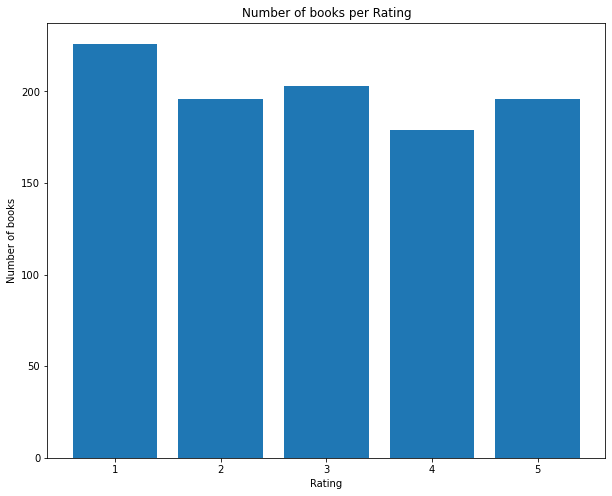

In [26]:
x = RatingCount.index
y = RatingCount["book_number"]
plt.figure(figsize=(10,8))
plt.bar(x=x, height=y)
plt.title("Number of books per Rating")
plt.xlabel("Rating")
plt.ylabel("Number of books")
plt.show()